# Anomaly Detection on the 40 MHz dataset

Baseline from: https://arxiv.org/pdf/2006.02516.pdf
Idea and datasets extracted from https://arxiv.org/pdf/2108.03986

- 56 inputs (18 objects (4 mu, 4 el, 10 jets) x pt, eta, phi + pt and phi of MET)

- The rest is just kept standard for now.
- Embedding: PolynomialEmbedding (n=3)
- Combined loss: $\mathcal{L} = \frac{1}{N}\sum_{i=1}^{N} \left( \log \left\| P \Phi({X_i}) \right\|_2^2 - 1 \right)^2 + \alpha \cdot \mathrm{ReLU}\left(\log(\|P\|_F^2)\right)$

**Imports**

In [1]:
import os
os.environ["KMP_WARNINGS"] = "0"
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2,3"
import jax
import jax.numpy as jnp
import numpy as np
import optax
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import auc
# import tensorflow as tf
from jax.nn.initializers import *
import matplotlib.pyplot as plt
import h5py

from tn4ml.initializers import *
from tn4ml.models.smpo import *
from tn4ml.models.model import *
from tn4ml.embeddings import *
from tn4ml.metrics import *
from tn4ml.util import *
from tn4ml.eval import *

In [2]:
jax.config.update("jax_enable_x64", True)
jax.config.update('jax_default_matmul_precision', 'highest')
jax.config.update("jax_platform_name", 'gpu')
print("JAX devices:", jax.devices())
print("PyTorch CUDA:", torch.cuda.is_available())

JAX devices: [CudaDevice(id=0), CudaDevice(id=1), CudaDevice(id=2), CudaDevice(id=3)]
PyTorch CUDA: True


**Load 40 MHz dataset**

In [3]:
import utils.dataloader as d

inputPath = "/global/cfs/cdirs/m2616/sagar/QiML/" #Change this based on wherever your datasets are located.
print(os.environ["HDF5_USE_FILE_LOCKING"]) #This should be false, otherwise there might be issues with reading the hdf5 files.

FALSE


In [13]:
batch_size = 10000
background = d.load_data(inputPath + "background_for_training.h5", batch_size=batch_size, shuffle=True, norm=False)

No normalization stats loaded.


In [14]:
print("Background shape before:", next(iter(background)).shape)

Background shape before: torch.Size([10000, 56])


**Training setup** &nbsp;
- Stochastic Gradient Descent

In [ ]:
# define model parameters
L = 56
initializer = gramschmidt('normal', 1e-1)
key = jax.random.PRNGKey(42)
shape_method = 'noteven'
bond_dim = 30
phys_dim = (4,4) #This will have to be tuned. dim = polynomial degree + 1
spacing = 8
add_identity = True
boundary='obc'

In [19]:
smpo = SMPO_initialize(L=L,
                        initializer=initializer,
                        key=key,
                        shape_method=shape_method,
                        spacing=spacing,
                        bond_dim=bond_dim,
                        phys_dim=phys_dim,
                        cyclic=False,
                        compress=True,
                        add_identity=add_identity,
                        boundary=boundary)

2025-05-31 07:33:37.834384: W external/xla/xla/tsl/framework/bfc_allocator.cc:501] Allocator (GPU_0_bfc) ran out of memory trying to allocate 512B (rounded to 512)requested by op 
2025-05-31 07:33:37.834727: W external/xla/xla/tsl/framework/bfc_allocator.cc:512] ****************************************************************************************************
E0531 07:33:37.834744 1228813 pjrt_stream_executor_client.cc:2839] Execution of replica 0 failed: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 512 bytes. [tf-allocator-allocation-error='']


ValueError: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 512 bytes.

In [ ]:
alpha = 0.4
def loss_combined(*args, **kwargs):
    error = LogQuadNorm
    reg = LogReLUFrobNorm
    return CombinedLoss(*args, **kwargs, error=error, reg=lambda P: alpha*reg(P))

In [ ]:
# define training parameters
arrays, skeleton = qtn.pack(smpo)
model = Model()
model_tn = qtn.unpack(arrays, skeleton)
model.__dict__.update(model_tn.__dict__)
model.L = len(model.tensors)
model.apply = smpo.apply

optimizer = optax.adam
strategy = 'global'
loss = loss_combined
train_type = TrainingType.UNSUPERVISED
embedding = PolynomialEmbedding(degree=3, n=1, include_bias=True)
learning_rate = 1e-4
earlystop = EarlyStopping(min_delta=0, patience=5, monitor='loss', mode='min')
device = 'gpu'

model.configure(optimizer=optimizer, strategy=strategy, loss=loss, train_type=train_type, learning_rate=learning_rate, device=device)

In [ ]:
print("Number of parameters in the model are: ", model.nparams())

Number of parameters in the model are:  245636


In [ ]:
def loss_fn(data, targets, *params):
    tn = smpo.copy(deep=True)  # use SMPO, not Model

    for t, p in zip(tn.tensors, params):
        t.modify(data=p)

    tn_i = embed(data, embedding)
    return model.loss(tn, tn_i)

loss_func = jax.jit(jax.vmap(loss_fn, in_axes=[0, None] + [None]*model.L), backend=model.device)
grads_func = jax.jit(jax.vmap(jax.grad(loss_fn, argnums=range(2, 2+model.L)), in_axes=[0, None] + [None]*model.L), backend=model.device)

params = model.arrays
model.step, model.opt_state = model.create_train_step(params=params, loss_func=loss_func, grads_func=grads_func)


In [ ]:
from tqdm import tqdm
import time

epochs = 100
history = {"learning_rate": learning_rate, 'loss': [], 'epoch_time': [], 'unfinished': True}

for epoch in range(epochs):
    start_time = time.time()
    epoch_loss = 0
    for i, batch in enumerate(tqdm(background, desc=f"Epoch {epoch+1}/{epochs}")):
        batch = jax.numpy.array(batch, dtype=jnp.float64)
        params = model.arrays
        params, model.opt_state, loss = model.step(params, model.opt_state, data=batch)
        model.update_tensors(params)
        epoch_loss += loss

    end_time = time.time()
    avg_loss = epoch_loss / len(background)
    history['loss'].append(avg_loss)
    history['epoch_time'].append(end_time - start_time)
    
    print(f"[Epoch {epoch+1}] Loss: {avg_loss:.6f} | Time: {end_time - start_time:.2f}s")
    history['unfinished'] = False  # training completed successfully

print("Final history:", history)


Epoch 1/100:   0%|          | 0/200 [00:00<?, ?it/s]2025-05-31 07:31:43.347246: E external/xla/xla/service/gpu/gpu_hlo_schedule.cc:652] The byte size of input/output arguments (39312685536) exceeds the base limit (31713951744). This indicates an error in the calculation!
2025-05-31 07:31:43.683716: W external/xla/xla/hlo/transforms/simplifiers/hlo_rematerialization.cc:3021] Can't reduce memory use below 0B (0 bytes) by rematerialization; only reduced to 54.83GiB (58875624304 bytes), down from 56.88GiB (61074410224 bytes) originally
2025-05-31 07:31:56.215625: W external/xla/xla/tsl/framework/bfc_allocator.cc:501] Allocator (GPU_0_bfc) ran out of memory trying to allocate 549.32MiB (rounded to 576000000)requested by op 
2025-05-31 07:31:56.215924: W external/xla/xla/tsl/framework/bfc_allocator.cc:512] ****************************************************************************************************
E0531 07:31:56.215962 1228813 pjrt_stream_executor_client.cc:2839] Execution of replica

In [13]:
def summarize_tn4ml_model(model):
    tensors = model.tensors

    print(f"Model class: {type(model).__name__}")
    print(f"Number of tensors (sites): {len(tensors)}")

    total_params = 0
    for i, tensor in enumerate(tensors):
        shape = tensor.shape
        numel = int(np.prod(shape))
        total_params += numel
        print(f"  Tensor {i:2d}: shape={shape}, num_elements={numel}")

    print(f"\nTotal number of parameters: {total_params:,}")
    print(f"Estimated memory (float64): {total_params * 8 / 1024**2:.2f} MB")

summarize_tn4ml_model(model)


Model class: Model
Number of tensors (sites): 56
  Tensor  0: shape=(4, 4, 4), num_elements=64
  Tensor  1: shape=(4, 16, 4), num_elements=256
  Tensor  2: shape=(16, 20, 4), num_elements=1280
  Tensor  3: shape=(20, 20, 4), num_elements=1600
  Tensor  4: shape=(20, 20, 4), num_elements=1600
  Tensor  5: shape=(20, 20, 4), num_elements=1600
  Tensor  6: shape=(20, 20, 4), num_elements=1600
  Tensor  7: shape=(20, 20, 4), num_elements=1600
  Tensor  8: shape=(20, 20, 4, 4), num_elements=6400
  Tensor  9: shape=(20, 20, 4), num_elements=1600
  Tensor 10: shape=(20, 20, 4), num_elements=1600
  Tensor 11: shape=(20, 20, 4), num_elements=1600
  Tensor 12: shape=(20, 20, 4), num_elements=1600
  Tensor 13: shape=(20, 20, 4), num_elements=1600
  Tensor 14: shape=(20, 20, 4), num_elements=1600
  Tensor 15: shape=(20, 20, 4), num_elements=1600
  Tensor 16: shape=(20, 20, 4, 4), num_elements=6400
  Tensor 17: shape=(20, 20, 4), num_elements=1600
  Tensor 18: shape=(20, 20, 4), num_elements=1600
 

Text(0.5, 1.0, 'Training Loss')

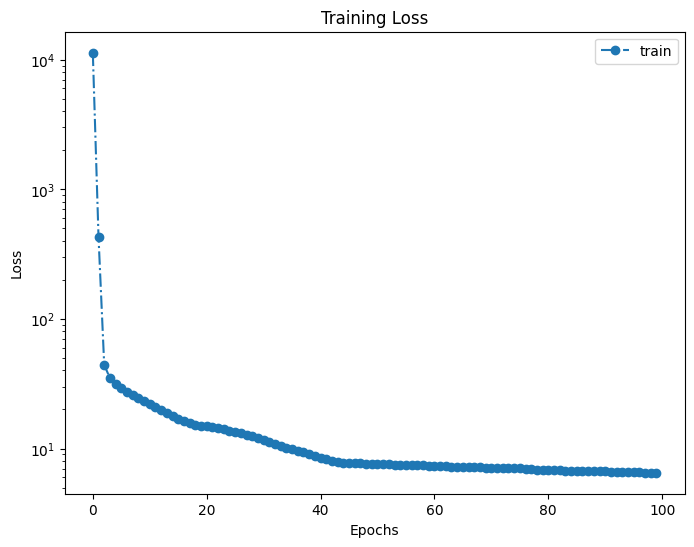

In [14]:
plt.figure(figsize=(8, 6))
plt.yscale('log')
plt.plot(range(len(history['loss'])), history['loss'], linestyle="-.", marker='o', label='train')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss')

**Evaluate**

In [16]:
a4l = d.load_data(inputPath + "Ato4l_lepFilter_13TeV.h5", batch_size=batch_size, shuffle=True)
lq = d.load_data(inputPath + "leptoquark_LOWMASS_lepFilter_13TeV.h5", batch_size=batch_size, shuffle=True)
htnu = d.load_data(inputPath + "hChToTauNu_13TeV_PU20.h5", batch_size=batch_size, shuffle=True)
htt = d.load_data(inputPath + "hToTauTau_13TeV_PU20.h5", batch_size=batch_size, shuffle=True)

No normalization stats loaded.
No normalization stats loaded.
No normalization stats loaded.
No normalization stats loaded.


In [ ]:
def evaluate_model(model, dataloader, loss_func, embedding, verbose=True):
    #total_loss = 0.0
    #total_samples = 0
    all_scores = []

    for batch in tqdm(dataloader, desc="Evaluating", disable=not verbose):
        batch = jax.numpy.array(batch, dtype=jnp.float64)
        params = model.arrays

        scores = loss_func(batch, None, *params)
        
        scores = jax.device_get(scores)
        all_scores.append(scores)
        # Compute mean loss
        #loss = loss_func(tn, embedded)
        #total_loss += loss.item() * batch.shape[0]
        #total_samples += batch.shape[0]

    return np.concatenate(all_scores)#, total_loss / total_samples


In [42]:
def loss_logquadnorm(data, targets, *params):
   tn = smpo.copy(deep=True)
   for t, p in zip(tn.tensors, params):
      t.modify(data=p)
   tn_i = embed(data, embedding)
   return LogQuadNorm(tn, tn_i)

loss_func_logquadnorm = jax.jit(jax.vmap(loss_logquadnorm, in_axes=[0, None] + [None]*model.L), backend=model.device)

In [43]:
# Run the evaluation on bkg and signals
bkg_score = evaluate_model(model, background, loss_func_logquadnorm, embedding, verbose=True)
a4l_score = evaluate_model(model, a4l, loss_func_logquadnorm, embedding, verbose=True)
lq_score = evaluate_model(model, lq, loss_func_logquadnorm, embedding, verbose=True)
htnu_score = evaluate_model(model, htnu, loss_func_logquadnorm, embedding, verbose=True)
htt_score  = evaluate_model(model, htt, loss_func_logquadnorm, embedding, verbose=True)

Evaluating: 100%|██████████| 70/70 [00:12<00:00,  5.66it/s]


**Plot anomaly scores and ROC curve**

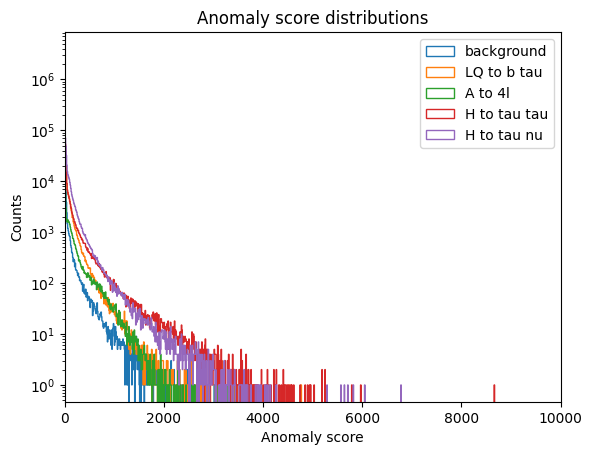

In [75]:
plt.figure()
plt.yscale('log')
xmax = 1e4
bins = np.linspace(0, xmax, 1000)
plt.hist(bkg_score, bins=bins, histtype='step', label='background')
plt.hist(lq_score, bins=bins, histtype='step', label='LQ to b tau')
plt.hist(a4l_score, bins=bins, histtype='step', label='A to 4l')
plt.hist(htt_score, bins=bins, histtype='step', label='H to tau tau')
plt.hist(htnu_score, bins=bins, histtype='step', label='H to tau nu')
plt.title('Anomaly score distributions')
plt.xlim([0, xmax])
plt.xlabel('Anomaly score')
plt.ylabel('Counts')
plt.legend()
plt.legend()
plt.show()

In [76]:
fpr_bkg, tpr_bkg = get_roc_curve_data(bkg_score, bkg_score, anomaly_det=True)
auc_bkg = auc(fpr_bkg, tpr_bkg)
# Find the score threshold corresponding to background FPR of 1e-5
idx_fpr = np.searchsorted(fpr_bkg, 1e-5, side="left")
if idx_fpr >= len(fpr_bkg):
   idx_fpr = -1
score_threshold = np.sort(bkg_score)[::-1][idx_fpr]
print("Anomaly score at FPR=1e-5:", score_threshold)

Anomaly score at FPR=1e-5: 1992.211765106565


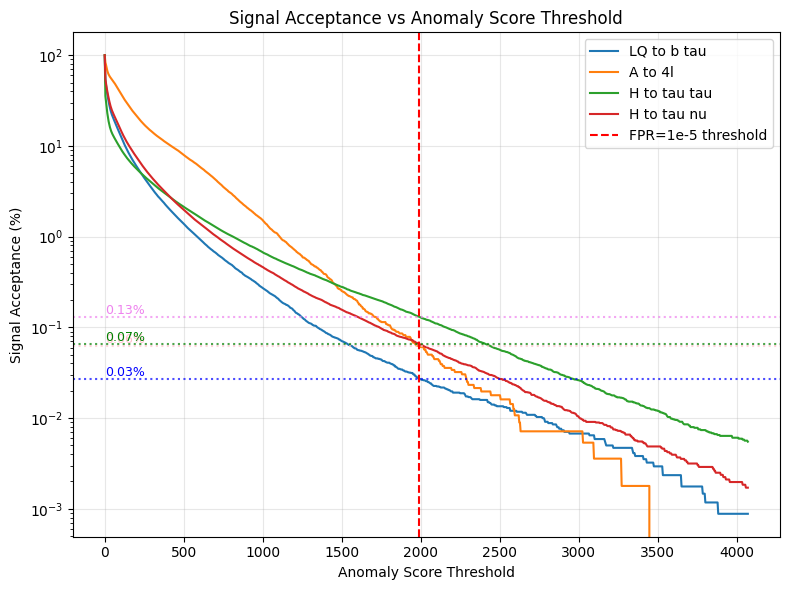

In [87]:
# Compute acceptance curves for each signal as a function of anomaly score threshold
thresholds = np.linspace(np.min(bkg_score), np.max(bkg_score), 1000)

def acceptance_curve(scores, thresholds):
   return np.array([(scores >= t).mean() for t in thresholds])

accept_lq = acceptance_curve(lq_score, thresholds)
accept_a4l = acceptance_curve(a4l_score, thresholds)
accept_htt = acceptance_curve(htt_score, thresholds)
accept_htnu = acceptance_curve(htnu_score, thresholds)

plt.figure(figsize=(8, 6))
plt.yscale('log')
plt.plot(thresholds, accept_lq * 100, label="LQ to b tau")
plt.plot(thresholds, accept_a4l * 100, label="A to 4l")
plt.plot(thresholds, accept_htt * 100, label="H to tau tau")
plt.plot(thresholds, accept_htnu * 100, label="H to tau nu")
# Add horizontal lines and text for acceptance at score_threshold for each signal
for accept, label, color in [
   (accept_lq, "LQ to b tau", "blue"),
   (accept_a4l, "A to 4l", "pink"),
   (accept_htt, "H to tau tau", "violet"),
   (accept_htnu, "H to tau nu", "green"),
]:
   idx = np.searchsorted(thresholds, score_threshold, side="left")
   if idx >= len(accept):
      idx = -1
   acc_val = accept[idx] * 100
   plt.axhline(y=acc_val, xmin=0, xmax=1, color=color, linestyle=":", alpha=0.7)
   plt.text(thresholds[0], acc_val, f"{acc_val:.2f}%", color=color, va="bottom", fontsize=9)
plt.axvline(score_threshold, color='red', linestyle='--', label='FPR=1e-5 threshold')
plt.xlabel("Anomaly Score Threshold")
plt.ylabel("Signal Acceptance (%)")
plt.title("Signal Acceptance vs Anomaly Score Threshold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [88]:
fpr_lq, tpr_lq = get_roc_curve_data(bkg_score, lq_score, anomaly_det=True)
auc_lq = auc(fpr_lq, tpr_lq)
fpr_a4l, tpr_a4l = get_roc_curve_data(bkg_score, a4l_score, anomaly_det=True)
auc_a4l = auc(fpr_a4l, tpr_a4l)
fpr_htt, tpr_htt = get_roc_curve_data(bkg_score, htt_score, anomaly_det=True)
auc_htt = auc(fpr_htt, tpr_htt)
fpr_htnu, tpr_htnu = get_roc_curve_data(bkg_score, htnu_score, anomaly_det=True)
auc_htnu = auc(fpr_htnu, tpr_htnu)

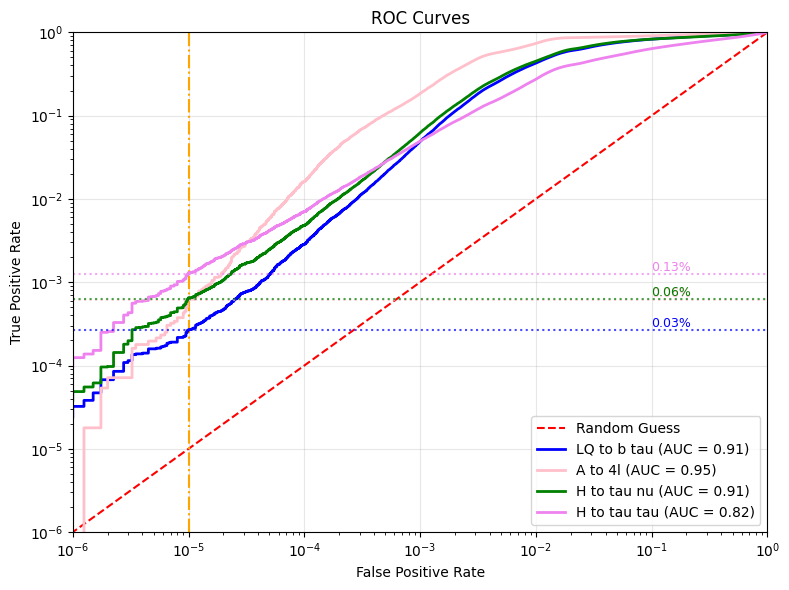

In [84]:
# Plot ROC curves
plt.figure(figsize=(8, 6))
plt.xscale('log')
plt.yscale('log')
plt.plot([0, 1], [0, 1], color="red", linestyle="--", label="Random Guess")
plt.axvline(1e-5, color="orange", linestyle="-.")
plt.plot(fpr_lq, tpr_lq, color="blue", lw=2, label=f"LQ to b tau (AUC = {auc_lq:.2f})")
plt.plot(fpr_a4l, tpr_a4l, color="pink", lw=2, label=f"A to 4l (AUC = {auc_a4l:.2f})")
plt.plot(fpr_htnu, tpr_htnu, color="green", lw=2, label=f"H to tau nu (AUC = {auc_htnu:.2f})")
plt.plot(fpr_htt, tpr_htt, color="violet", lw=2, label=f"H to tau tau (AUC = {auc_htt:.2f})")

# Add horizontal lines and text for TPR at FPR=1e-5 for each signal
for fpr, tpr, color, label in [
   (fpr_lq, tpr_lq, "blue", "LQ to b tau"),
   (fpr_a4l, tpr_a4l, "pink", "A to 4l"),
   (fpr_htnu, tpr_htnu, "green", "H to tau nu"),
   (fpr_htt, tpr_htt, "violet", "H to tau tau"),
]:
   # Find the TPR at FPR closest to 1e-5
   idx = np.searchsorted(fpr, 1e-5, side="left")
   if idx >= len(tpr):
      idx = -1
   tpr_val = tpr[idx]
   plt.axhline(y=tpr_val, xmin=0, xmax=1, color=color, linestyle=":", alpha=0.7)
   plt.text(1e-1, tpr_val, f"{tpr_val*100:.2f}%", color=color, va="bottom", fontsize=9)
plt.xlim([1e-6, 1.0])
plt.ylim([1e-6, 1.0])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()